In [1]:
import pandas as pd
import numpy as np
import cv2

# -------------------------
# Paths – AJUSTAR si cambian los nombres
# -------------------------
TRACKS_CSV = "video01/vehicle_tracks_yolo_with_id.csv"
GT_XML     = "video01/vehicles_with_speed.xml"
LANES_XML  = "lanes.xml"
VIDEO_PATH = "video01/video.mp4"

FPS_NOMINAL = 25.0  # fallback

# -------------------------
# Cargar tracks YOLO
# -------------------------
df_tracks = pd.read_csv(TRACKS_CSV)
print("Tracks cargados:", df_tracks.shape)

# bottom-center de cada bbox
df_tracks["px"] = (df_tracks["x1"] + df_tracks["x2"]) / 2
df_tracks["py"] = df_tracks["y2"]

df_tracks["vehicle_id"] = df_tracks["vehicle_id"].astype("Int64")
df_tracks["lane"] = df_tracks["lane"].astype("Int64")

display(df_tracks.head())


# -------------------------
# Cargar ground truth del radar
# -------------------------
import xml.etree.ElementTree as ET

def load_ground_truth_from_xml(xml_path):
    tree = ET.parse(str(xml_path))
    root = tree.getroot()

    rows = []
    for v in root.findall(".//vehicle"):
        vid = v.get("vehicle_id")
        radar = v.find("radar")
        if radar is None:
            continue
        speed = radar.get("speed")
        if speed is None:
            continue

        rows.append({
            "vehicle_id": int(vid),
            "gt_speed": float(speed),
            "lane": int(v.get("lane")) if v.get("lane") is not None else None,
        })

    return pd.DataFrame(rows)

df_gt = load_ground_truth_from_xml(GT_XML)
print("GT cargado:", df_gt.shape)
display(df_gt.head())


# -------------------------
# Cargar homografías desde lanes.xml
# -------------------------
def parse_lanes_xml(xml_path):
    import xml.etree.ElementTree as ET

    REAL_WIDTH = 2.0   # m
    REAL_LENGTH = 4.8  # m

    real_world_points = np.array([
        [0, 0],
        [REAL_WIDTH, 0],
        [0, REAL_LENGTH],
        [REAL_WIDTH, REAL_LENGTH]
    ], dtype=np.float32)

    tree = ET.parse(str(xml_path))
    root = tree.getroot()

    lane_configs = {}
    for measure in root.findall(".//measure"):
        lane_id = int(measure.get("id"))
        pts = []
        for tag in ["pTopLeft", "pTopRight", "pBotLeft", "pBotRight"]:
            node = measure.find(tag)
            x = float(node.get("x"))
            y = float(node.get("y"))
            pts.append([x, y])
        dst = np.array(pts, dtype=np.float32)

        H, _ = cv2.findHomography(dst, real_world_points)

        y_min = dst[:, 1].min()
        y_max = dst[:, 1].max()

        lane_configs[lane_id] = {
            "H": H,
            "trap_limits": {"y_min": y_min, "y_max": y_max},
        }
    return lane_configs

lane_configs = parse_lanes_xml(LANES_XML)
print("Lanes cargados:", lane_configs.keys())


# -------------------------
# Cargar FPS real del video
# -------------------------
def get_video_fps(path):
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    if fps > 0:
        print(f"FPS leído del video: {fps}")
        return fps
    print("FPS inválido, usando nominal =", FPS_NOMINAL)
    return FPS_NOMINAL

fps_video = get_video_fps(VIDEO_PATH)


Tracks cargados: (14100, 17)


,video_id,frame,track_id,class_id,class_name,conf,x1,y1,x2,y2,img_w,img_h,fps,center_x,center_y,vehicle_id,lane,px,py
0,video,0,1,2,car,0.422626,334.997620,0.0,549.908020,53.978405,1920,1080,25.0,442.452820,26.989202,<NA>,<NA>,442.452820,53.978405
1,video,0,2,7,truck,0.377719,1058.240112,0.0,1343.984985,93.138657,1920,1080,25.0,1201.112549,46.569328,<NA>,<NA>,1201.112549,93.138657
2,video,1,1,2,car,0.523622,359.220612,0.0,535.078064,43.986061,1920,1080,25.0,447.149338,21.993031,<NA>,<NA>,447.149338,43.986061
3,video,1,2,7,truck,0.518423,1077.124634,0.0,1305.382446,74.068459,1920,1080,25.0,1191.253540,37.034229,<NA>,<NA>,1191.253540,74.068459
4,video,2,2,7,truck,0.352585,1087.623535,0.0,1269.353271,58.196693,1920,1080,25.0,1178.488403,29.098347,<NA>,<NA>,1178.488403,58.196693


GT cargado: (110, 3)


,vehicle_id,gt_speed,lane
0,1,56.65,3
1,2,53.74,3
2,3,52.13,2
3,4,49.06,3
4,5,50.51,2


Lanes cargados: dict_keys([1, 2, 3])
FPS leído del video: 25.0


In [2]:
import numpy as np

def pixel_to_world(H, u, v):
    """
    Convierte un punto en píxeles al plano de mundo usando la homografía H.

    Parámetros:
      - H: Matriz 3x3 de homografía.
      - u, v: Coordenadas en píxeles.

    Returns:
      - (x, y): Coordenadas en metros en el plano de la ruta.
    """
    p = np.array([u, v, 1.0], dtype=np.float32)
    w = H @ p
    w /= w[2]
    return float(w[0]), float(w[1])


def compute_speed_trap_regression(df_tracks, lane_configs, fps,
                                  margin_px=10, min_frames=5, use_axis="y"):
    """
    Calcula la velocidad de cada vehículo usando regresión s(t) dentro de la speed trap.

    Pasos:
      - Filtra frames donde el bottom del bbox está dentro de [y_min - margin, y_max + margin].
      - Proyecta cada punto (px, py) a mundo con H del carril.
      - Usa la coord 'y' como posición s(t) (eje de avance del auto).
      - Ajusta una recta s(t) = a * t + b y toma |a| como velocidad (m/s).

    Parámetros:
      - df_tracks: DataFrame con los tracks de YOLO (frame, px, py, vehicle_id, lane).
      - lane_configs: dict con homografía y trap_limits por carril.
      - fps: FPS del video.
      - margin_px: margen en píxeles extra alrededor de la trap.
      - min_frames: mínimo de frames dentro de la trap para estimar velocidad.
      - use_axis: 'y', 'x' o 'norm' para elegir la coordenada de posición.

    Returns:
      - DataFrame con columnas: vehicle_id, lane, speed_trap_reg, dist_m, delta_frames, n_points.
    """
    rows = []
    df_valid = df_tracks.dropna(subset=["vehicle_id"]).copy()
    df_valid["vehicle_id"] = df_valid["vehicle_id"].astype(int)

    for vid, df_v in df_valid.groupby("vehicle_id"):
        lane = df_v["lane"].iloc[0] if "lane" in df_v.columns else None
        if lane not in lane_configs:
            continue

        cfg = lane_configs[lane]
        H = cfg["H"]
        y_min = cfg["trap_limits"]["y_min"] - margin_px
        y_max = cfg["trap_limits"]["y_max"] + margin_px

        # Solo frames donde el bbox está dentro de la speed trap
        df_zone = df_v[(df_v["py"] >= y_min) & (df_v["py"] <= y_max)].sort_values("frame")
        if len(df_zone) < min_frames:
            continue

        # Tiempo en segundos
        t = df_zone["frame"].to_numpy() / fps

        xs, ys = [], []
        for _, row in df_zone.iterrows():
            xw, yw = pixel_to_world(H, row["px"], row["py"])
            xs.append(xw)
            ys.append(yw)
        xs = np.array(xs)
        ys = np.array(ys)

        if use_axis == "y":
            s = ys
        elif use_axis == "x":
            s = xs
        else:  # 'norm'
            s = np.sqrt(xs**2 + ys**2)

        if len(t) < 2 or np.allclose(t, t[0]):
            continue

        # Ajuste lineal s(t) = a * t + b
        a, b = np.polyfit(t, s, 1)  # a en m/s

        # IMPORTANTE: tomamos el módulo de la pendiente (la velocidad no puede ser negativa)
        speed_mps = abs(a)
        speed_kmh = speed_mps * 3.6

        dist_m = s[-1] - s[0]
        delta_frames = df_zone["frame"].iloc[-1] - df_zone["frame"].iloc[0]

        rows.append({
            "vehicle_id": vid,
            "lane": lane,
            "speed_trap_reg": speed_kmh,
            "dist_m": float(dist_m),
            "delta_frames": int(delta_frames),
            "n_points": len(df_zone),
        })

    df_reg = pd.DataFrame(rows)
    print(f"Trap+Regresión: vehículos con velocidad estimada: {df_reg.shape[0]}")
    return df_reg



In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_predictions(df, pred_col="pred_speed", gt_col="gt_speed", verbose=True):
    """
    Calcula MAE, RMSE, MAPE y R^2 para una columna de predicción vs ground truth.

    Parámetros:
      - df: DataFrame con columnas de verdad y predicción.
      - pred_col: nombre de la columna con las velocidades estimadas.
      - gt_col: nombre de la columna con las velocidades reales.

    Returns:
      - dict con las métricas calculadas.
    """
    y_true = df[gt_col].to_numpy()
    y_pred = df[pred_col].to_numpy()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)   # sklearn viejo: no acepta squared=False
    rmse = math.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE_%": mape, "R2": r2}
    if verbose:
        print(f"MAE  = {mae:.2f} km/h")
        print(f"RMSE = {rmse:.2f} km/h")
        print(f"MAPE = {mape:.1f} %")
        print(f"R²   = {r2:.3f}")
    return metrics


def scatter_real_vs_est(df, pred_col="pred_speed", gt_col="gt_speed",
                        title="Real vs Estimado", subtitle=""):
    """
    Grafica velocidades reales vs estimadas con la recta ideal y = x.
    """
    plt.figure(figsize=(6, 5))
    plt.scatter(df[gt_col], df[pred_col], alpha=0.7)
    min_v = min(df[gt_col].min(), df[pred_col].min()) * 0.9
    max_v = max(df[gt_col].max(), df[pred_col].max()) * 1.1
    plt.plot([min_v, max_v], [min_v, max_v], "r--", label="Ideal (y = x)")
    plt.xlabel("Velocidad Real (Radar) [km/h]")
    plt.ylabel("Velocidad Estimada [km/h]")
    plt.title(f"{title}\n{subtitle}")
    plt.legend()
    plt.grid(True)
    plt.show()


Trap+Regresión: vehículos con velocidad estimada: 91
Vehículos con predicción y radar: 91
MAE  = 18.77 km/h
RMSE = 19.35 km/h
MAPE = 41.8 %
R²   = -2.142


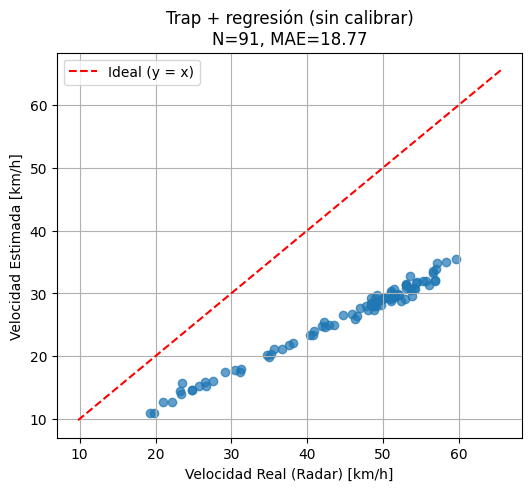

In [4]:
# Calculamos velocidades con trap + regresión usando el FPS del video
df_trap_reg = compute_speed_trap_regression(
    df_tracks=df_tracks,
    lane_configs=lane_configs,
    fps=fps_video,
    margin_px=10,
    min_frames=5,
    use_axis="y",
)

# Juntamos con las velocidades reales del radar
df_trap_reg_eval = df_trap_reg.merge(
    df_gt[["vehicle_id", "gt_speed"]],
    on="vehicle_id",
    how="inner",
)

print("Vehículos con predicción y radar:", df_trap_reg_eval.shape[0])

# Métricas sin calibrar, para tener referencia
metrics_trap_reg_raw = evaluate_predictions(
    df_trap_reg_eval,
    pred_col="speed_trap_reg",
    gt_col="gt_speed",
)

scatter_real_vs_est(
    df_trap_reg_eval,
    pred_col="speed_trap_reg",
    gt_col="gt_speed",
    title="Trap + regresión (sin calibrar)",
    subtitle=f"N={df_trap_reg_eval.shape[0]}, MAE={metrics_trap_reg_raw['MAE']:.2f}",
)


In [5]:
from numpy.random import default_rng

def split_calib_test(df_eval, calib_frac=0.3, seed=0):
    """
    Separa los vehicle_id en calibración y test.

    Parámetros:
      - df_eval: DataFrame con 'vehicle_id'.
      - calib_frac: fracción aproximada para calibración.
      - seed: semilla aleatoria.

    Returns:
      - calib_ids: set de IDs de calibración.
      - test_ids: set de IDs de test.
    """
    ids = df_eval["vehicle_id"].dropna().unique()
    rng = default_rng(seed)
    rng.shuffle(ids)

    n_calib = max(5, int(len(ids) * calib_frac))
    calib_ids = set(ids[:n_calib])
    test_ids  = set(ids[n_calib:])

    print(f"Total vehículos con radar: {len(ids)}")
    print(f"  Calibración: {len(calib_ids)}")
    print(f"  Test:        {len(test_ids)}")
    return calib_ids, test_ids

calib_ids, test_ids = split_calib_test(df_trap_reg_eval, calib_frac=0.3, seed=0)


Total vehículos con radar: 91
  Calibración: 27
  Test:        64


In [6]:
def calibrate_lane_scales(df_eval, calib_ids,
                          pred_col="speed_trap_reg",
                          gt_col="gt_speed",
                          lane_col="lane",
                          min_samples=4):
    """
    Ajusta un factor de escala K_lane por carril usando SOLO vehículos de calibración.

    Se asume gt ≈ K_lane * pred y se calcula K_lane = sum(x*y)/sum(x^2)
    (regresión sin término independiente) por carril.

    Parámetros:
      - df_eval: DataFrame con predicciones y gt.
      - calib_ids: set de vehicle_id para calibración.
      - pred_col, gt_col, lane_col: nombres de columnas.
      - min_samples: mínimo de vehículos por carril.

    Returns:
      - lane_scales: dict {lane -> K_lane}
      - df_calib: DataFrame de calibración con columna 'pred_calib'.
    """
    df_calib = df_eval[df_eval["vehicle_id"].isin(calib_ids)].copy()

    lane_scales = {}
    for lane, df_lane in df_calib.groupby(lane_col):
        x = df_lane[pred_col].to_numpy()
        y = df_lane[gt_col].to_numpy()
        mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
        x = x[mask]
        y = y[mask]

        if len(x) < min_samples:
            print(f"Lane {lane}: pocos datos ({len(x)}), K_lane = 1.0 (sin calibrar).")
            lane_scales[lane] = 1.0
            continue

        K = np.sum(x * y) / np.sum(x * x)
        lane_scales[lane] = K
        print(f"Lane {lane}: n={len(x)}, K_lane={K:.4f}")

    df_calib["pred_calib"] = df_calib.apply(
        lambda r: r[pred_col] * lane_scales.get(r[lane_col], 1.0),
        axis=1
    )

    return lane_scales, df_calib

lane_scales, df_calib_scaled = calibrate_lane_scales(
    df_trap_reg_eval,
    calib_ids,
    pred_col="speed_trap_reg",
    gt_col="gt_speed",
    lane_col="lane",
    min_samples=4,
)

lane_scales


Lane 1: n=9, K_lane=1.6916
Lane 2: n=9, K_lane=1.7036
Lane 3: n=9, K_lane=1.7407


{1: 1.691643234487755, 2: 1.7036207750842118, 3: 1.7406938100551954}

=== CALIB (solo para ver que ajusta, NO reportar esto como resultado final) ===
MAE  = 0.74 km/h
RMSE = 0.97 km/h
MAPE = 1.6 %
R²   = 0.992

=== TEST (estos son los números que van al informe) ===
MAE  = 0.77 km/h
RMSE = 1.06 km/h
MAPE = 1.8 %
R²   = 0.991


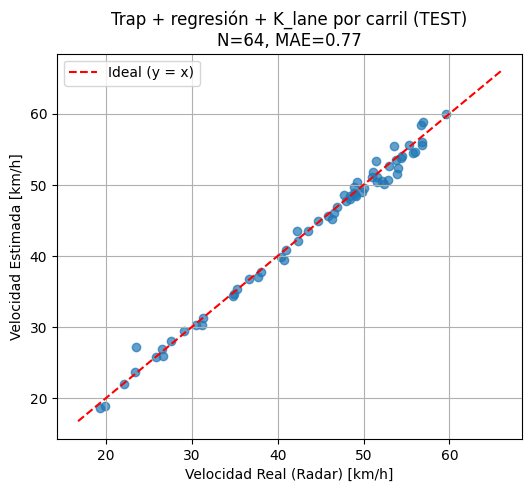

In [7]:
# Aplicamos K_lane a TODAS las predicciones (no usamos gt de cada auto)
df_trap_reg_eval["speed_trap_reg_lane_cal"] = df_trap_reg_eval.apply(
    lambda r: r["speed_trap_reg"] * lane_scales.get(r["lane"], 1.0),
    axis=1
)

# Armamos dataframes de calib y test
df_trap_reg_eval_calib = df_trap_reg_eval[df_trap_reg_eval["vehicle_id"].isin(calib_ids)]
df_trap_reg_eval_test  = df_trap_reg_eval[df_trap_reg_eval["vehicle_id"].isin(test_ids)]

print("=== CALIB (solo para ver que ajusta, NO reportar esto como resultado final) ===")
metrics_calib = evaluate_predictions(
    df_trap_reg_eval_calib,
    pred_col="speed_trap_reg_lane_cal",
    gt_col="gt_speed",
)

print("\n=== TEST (estos son los números que van al informe) ===")
metrics_test = evaluate_predictions(
    df_trap_reg_eval_test,
    pred_col="speed_trap_reg_lane_cal",
    gt_col="gt_speed",
)

scatter_real_vs_est(
    df_trap_reg_eval_test,
    pred_col="speed_trap_reg_lane_cal",
    gt_col="gt_speed",
    title="Trap + regresión + K_lane por carril (TEST)",
    subtitle=f"N={df_trap_reg_eval_test.shape[0]}, MAE={metrics_test['MAE']:.2f}",
)


In [8]:
# ==========================
# CONFIG VIDEO + MODELO LP
# ==========================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytesseract
from ultralytics import YOLO

# Igual que en speed.ipynb
VIDEO_PATH = "video01/video.mp4"   # ajustá si lo tenés en otro lado
LP_MODEL_PATH = "license_plate_detector.pt"  # pesos del repo YOLOv8-ALPR
SPEED_LIMIT = 50.0  # km/h

print("VIDEO_PATH:", VIDEO_PATH, "| existe:", os.path.exists(VIDEO_PATH))
print("LP_MODEL_PATH:", LP_MODEL_PATH, "| existe:", os.path.exists(LP_MODEL_PATH))

# Si querés, seteá el binario de Tesseract en Windows
# pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Cargar modelo de patentes
lp_model = YOLO(LP_MODEL_PATH)
print("✅ Modelo de matrículas cargado.")


VIDEO_PATH: video01/video.mp4 | existe: True
LP_MODEL_PATH: license_plate_detector.pt | existe: True
✅ Modelo de matrículas cargado.


In [9]:
# ==============================
# HELPERS DE VIDEO Y GEOMETRÍA
# ==============================

def load_frame(frame_idx, video_path=VIDEO_PATH):
    """
    Devuelve el frame 'frame_idx' del video como imagen BGR.

    Parámetros:
      - frame_idx: número de frame (0-based).
      - video_path: ruta al video (string).

    Returns:
      - frame BGR (np.ndarray).

    Lanza error claro si no se puede abrir o leer.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        raise FileNotFoundError(
            f"No se pudo abrir el video: {video_path}. "
            "Revisá la ruta y el directorio de trabajo (mismo que en speed.ipynb)."
        )

    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()

    if not ok or frame is None:
        raise RuntimeError(f"No se pudo leer el frame {frame_idx} del video {video_path}.")

    return frame


def choose_frame_in_trap(df_v, cfg_lane):
    """
    Elige un frame representativo del vehículo dentro de la speed trap.

    Usa el frame cuyo py está más cerca del centro de la trap.
    Si no hay ningún frame en la trap, devuelve None.
    """
    y_min = cfg_lane["trap_limits"]["y_min"]
    y_max = cfg_lane["trap_limits"]["y_max"]
    y_c   = 0.5 * (y_min + y_max)

    df_zone = df_v[(df_v["py"] >= y_min) & (df_v["py"] <= y_max)]
    if df_zone.empty:
        return None

    idx = (df_zone["py"] - y_c).abs().idxmin()
    return df_zone.loc[idx]


def box_iou(boxA, boxB):
    """
    IoU entre dos cajas [x1,y1,x2,y2].

    Sirve para matchear la placa detectada con el vehículo correcto.
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH

    areaA = max(0, boxA[2] - boxA[0]) * max(0, boxA[3] - boxA[1])
    areaB = max(0, boxB[2] - boxB[0]) * max(0, boxB[3] - boxB[1])

    denom = areaA + areaB - interArea + 1e-9
    return interArea / denom


In [10]:
# =========================================
# DETECCIÓN DE PATENTE + OCR CON TESSERACT
# =========================================

def detect_plate_yolo_fullframe(frame_bgr, car_bbox, model, conf_th=0.2, min_iou=0.05):
    """
    Corre YOLO de matrículas sobre el frame completo y se queda con
    la detección que mejor se solapa con el bbox del auto.

    Parámetros:
      - frame_bgr: frame completo (BGR).
      - car_bbox: (x1,y1,x2,y2) del vehículo.
      - model: modelo YOLO de matrículas.
      - conf_th: confianza mínima para aceptar una detección.
      - min_iou: IoU mínima con el auto.

    Returns:
      - crop_lp: recorte BGR de la matrícula o None.
      - plate_box: bbox [x1,y1,x2,y2] en coordenadas del frame o None.
    """
    results = model.predict(frame_bgr, verbose=False)
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None, None

    car_box = list(map(int, car_bbox))
    best_box = None
    best_score = 0.0

    for b in boxes:
        conf = float(b.conf)
        if conf < conf_th:
            continue
        bx1, by1, bx2, by2 = b.xyxy[0].tolist()
        det_box = [int(bx1), int(by1), int(bx2), int(by2)]
        iou = box_iou(car_box, det_box)
        if iou < min_iou:
            continue
        # Score combinado de confianza + IoU
        score = conf * (0.5 + 0.5 * iou)
        if score > best_score:
            best_score = score
            best_box = det_box

    if best_box is None:
        return None, None

    x1, y1, x2, y2 = best_box
    H, W = frame_bgr.shape[:2]
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = min(W, x2); y2 = min(H, y2)
    crop = frame_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        return None, None

    return crop, best_box


def ocr_plate(crop_bgr):
    """
    Lee texto de una matrícula usando Tesseract.

    Parámetros:
      - crop_bgr: recorte BGR de la placa.

    Returns:
      - string con letras/números, sin espacios, en mayúsculas.
    """
    if crop_bgr is None or crop_bgr.size == 0:
        return ""

    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 9, 75, 75)
    th = cv2.adaptiveThreshold(gray, 255,
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY,
                               35, 5)

    config = "--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    txt = pytesseract.image_to_string(th, config=config)
    txt = txt.strip().replace(" ", "").upper()
    txt = "".join(ch for ch in txt if ch.isalnum())
    return txt


In [11]:
# =========================================
# DETECCIÓN DE PATENTE + OCR CON TESSERACT
# =========================================

def detect_plate_yolo_fullframe(frame_bgr, car_bbox, model, conf_th=0.2, min_iou=0.05):
    """
    Corre YOLO de matrículas sobre el frame completo y se queda con
    la detección que mejor se solapa con el bbox del auto.

    Parámetros:
      - frame_bgr: frame completo (BGR).
      - car_bbox: (x1,y1,x2,y2) del vehículo.
      - model: modelo YOLO de matrículas.
      - conf_th: confianza mínima para aceptar una detección.
      - min_iou: IoU mínima con el auto.

    Returns:
      - crop_lp: recorte BGR de la matrícula o None.
      - plate_box: bbox [x1,y1,x2,y2] en coordenadas del frame o None.
    """
    results = model.predict(frame_bgr, verbose=False)
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None, None

    car_box = list(map(int, car_bbox))
    best_box = None
    best_score = 0.0

    for b in boxes:
        conf = float(b.conf)
        if conf < conf_th:
            continue
        bx1, by1, bx2, by2 = b.xyxy[0].tolist()
        det_box = [int(bx1), int(by1), int(bx2), int(by2)]
        iou = box_iou(car_box, det_box)
        if iou < min_iou:
            continue
        # Score combinado de confianza + IoU
        score = conf * (0.5 + 0.5 * iou)
        if score > best_score:
            best_score = score
            best_box = det_box

    if best_box is None:
        return None, None

    x1, y1, x2, y2 = best_box
    H, W = frame_bgr.shape[:2]
    x1 = max(0, x1); y1 = max(0, y1)
    x2 = min(W, x2); y2 = min(H, y2)
    crop = frame_bgr[y1:y2, x1:x2]
    if crop.size == 0:
        return None, None

    return crop, best_box


def ocr_plate(crop_bgr):
    """
    Lee texto de una matrícula usando Tesseract.

    Parámetros:
      - crop_bgr: recorte BGR de la placa.

    Returns:
      - string con letras/números, sin espacios, en mayúsculas.
    """
    if crop_bgr is None or crop_bgr.size == 0:
        return ""

    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.bilateralFilter(gray, 9, 75, 75)
    th = cv2.adaptiveThreshold(gray, 255,
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY,
                               35, 5)

    config = "--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    txt = pytesseract.image_to_string(th, config=config)
    txt = txt.strip().replace(" ", "").upper()
    txt = "".join(ch for ch in txt if ch.isalnum())
    return txt


In [12]:
# ============================================
# PIPELINE: VELOCIDAD + MATRÍCULA (YOLO + OCR)
# ============================================

import pytesseract
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"



def build_speed_plate_table_yolo(df_tracks, df_speed_eval, lane_configs,
                                 lp_model,
                                 speed_col="speed_trap_reg_lane_cal",
                                 speed_limit=SPEED_LIMIT):
    """
    Para cada vehículo con velocidad estimada:
      - Elige un frame (trap si se puede, sino centro del track).
      - Corre YOLO de matrículas sobre el frame completo.
      - Matchea la placa con el auto por IoU.
      - Hace OCR sobre el recorte de la matrícula.

    Devuelve un DataFrame con:
      vehicle_id, lane, speed_est, gt_speed,
      is_speeding_pred, is_speeding_gt,
      plate_text, plate_bbox
    """
    rows = []

    df_tracks_v = df_tracks.dropna(subset=["vehicle_id"]).copy()
    df_tracks_v["vehicle_id"] = df_tracks_v["vehicle_id"].astype(int)

    n_no_frame = 0
    n_no_det = 0
    n_det = 0
    n_ocr_nonempty = 0

    for _, row_s in df_speed_eval.iterrows():
        vid = int(row_s["vehicle_id"])
        lane = row_s.get("lane", None)
        speed_est = float(row_s[speed_col])
        gt = float(row_s["gt_speed"])

        df_v = df_tracks_v[df_tracks_v["vehicle_id"] == vid]

        def append_row(plate_text="", plate_bbox=None):
            rows.append({
                "vehicle_id": vid,
                "lane": lane,
                "speed_est": speed_est,
                "gt_speed": gt,
                "is_speeding_pred": speed_est > speed_limit,
                "is_speeding_gt": gt > speed_limit,
                "plate_text": plate_text,
                "plate_bbox": plate_bbox,
            })

        if df_v.empty or lane not in lane_configs:
            append_row()
            continue

        cfg_lane = lane_configs[lane]
        pick = choose_frame_in_trap(df_v, cfg_lane)
        if pick is None:
            pick = df_v.sort_values("frame").iloc[len(df_v) // 2]

        frame_idx = int(pick["frame"])

        try:
            frame = load_frame(frame_idx)
        except Exception as e:
            n_no_frame += 1
            append_row()
            continue

        car_bbox = (pick["x1"], pick["y1"], pick["x2"], pick["y2"])

        crop_lp, plate_bbox = detect_plate_yolo_fullframe(
            frame, car_bbox, lp_model,
            conf_th=0.15,   # podés subir/bajar esto para más/menos detecciones
            min_iou=0.02    # muy bajo para no perder detecciones cerca
        )

        if crop_lp is None:
            n_no_det += 1
            append_row()
            continue

        n_det += 1
        plate_text = ocr_plate(crop_lp)
        if plate_text:
            n_ocr_nonempty += 1

        append_row(plate_text=plate_text, plate_bbox=plate_bbox)

    df_sp = pd.DataFrame(rows)
    print("Vehículos procesados           :", df_sp.shape[0])
    print("Frames no leídos del video     :", n_no_frame)
    print("Sin detección de matrícula YOLO:", n_no_det)
    print("Con detección de matrícula YOLO:", n_det)
    print("Con texto OCR no vacío         :", n_ocr_nonempty)

    display(df_sp.head())
    return df_sp


df_speed_plate = build_speed_plate_table_yolo(
    df_tracks=df_tracks,
    df_speed_eval=df_trap_reg_eval,
    lane_configs=lane_configs,
    lp_model=lp_model,
    speed_col="speed_trap_reg_lane_cal",
    speed_limit=SPEED_LIMIT,
)


Vehículos procesados           : 91
Frames no leídos del video     : 0
Sin detección de matrícula YOLO: 13
Con detección de matrícula YOLO: 78
Con texto OCR no vacío         : 36


,vehicle_id,lane,speed_est,gt_speed,is_speeding_pred,is_speeding_gt,plate_text,plate_bbox
0,1,3.0,58.370781,56.65,True,True,RUE,"[1174, 162, 1284, 205]"
1,2,3.0,53.508414,53.74,True,True,CO,"[1161, 142, 1246, 186]"
2,3,2.0,50.582505,52.13,True,True,M,"[758, 138, 850, 180]"
3,4,3.0,48.592199,49.06,False,False,,"[1204, 92, 1275, 136]"
4,5,2.0,50.174985,50.51,True,True,M,"[741, 158, 822, 196]"


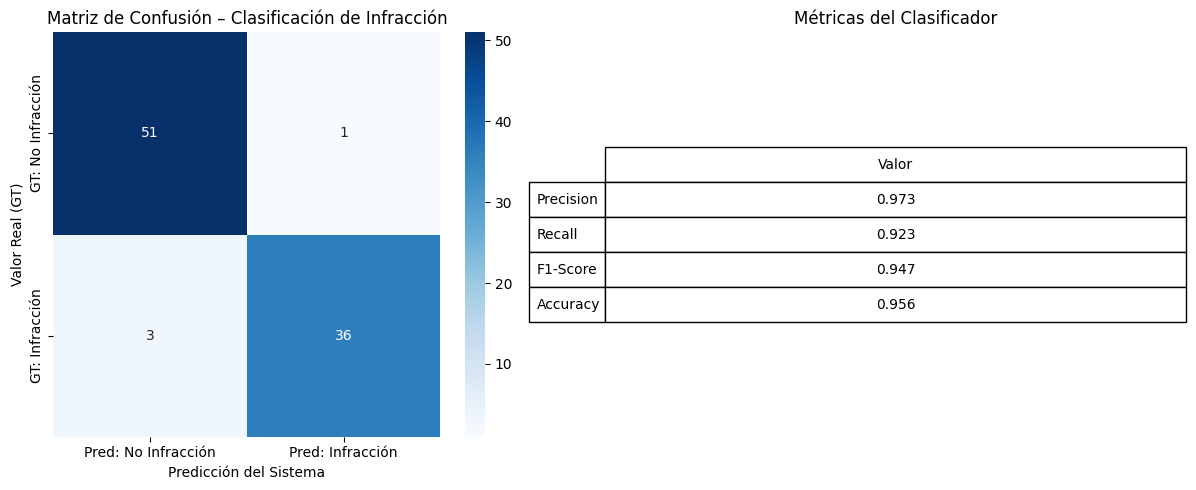

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# ============================
#  Computar métricas
# ============================

y_true = df_speed_plate["is_speeding_gt"].astype(bool).to_numpy()
y_pred = df_speed_plate["is_speeding_pred"].astype(bool).to_numpy()

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[False, True]).ravel()

precision  = precision_score(y_true, y_pred, zero_division=0)
recall     = recall_score(y_true, y_pred, zero_division=0)
f1         = f1_score(y_true, y_pred, zero_division=0)
accuracy   = accuracy_score(y_true, y_pred)

# Para la tabla
metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-Score", "Accuracy"],
    "Value":  [precision,   recall,   f1,         accuracy]
})

# ============================
#  FIGURA UNIFICADA
# ============================

fig = plt.figure(figsize=(12, 5))

# ---- Subplot 1: Confusion Matrix ----
ax1 = fig.add_subplot(1, 2, 1)

cm_df = pd.DataFrame([[tn, fp],
                      [fn, tp]],
                     index=["GT: No Infracción", "GT: Infracción"],
                     columns=["Pred: No Infracción", "Pred: Infracción"])

sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax1)
ax1.set_title("Matriz de Confusión – Clasificación de Infracción")
ax1.set_ylabel("Valor Real (GT)")
ax1.set_xlabel("Predicción del Sistema")

# ---- Subplot 2: Tabla de métricas ----
ax2 = fig.add_subplot(1, 2, 2)
ax2.axis("off")

table = ax2.table(
    cellText=[[f"{v:.3f}" if isinstance(v, float) else v] for v in metrics_df["Value"]],
    rowLabels=metrics_df["Metric"],
    colLabels=["Valor"],
    cellLoc="center",
    loc="center"
)
table.scale(1.2, 2.0)
ax2.set_title("Métricas del Clasificador")

plt.tight_layout()
plt.show()


In [14]:
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import cv2
import numpy as np

@dataclass
class EdgeRegion:
    x: int
    y: int
    w: int
    h: int

    @property
    def x2(self) -> int:
        return self.x + self.w

    @property
    def y2(self) -> int:
        return self.y + self.h

    @property
    def cx(self) -> float:
        return self.x + self.w / 2.0

    @property
    def cy(self) -> float:
        return self.y + self.h / 2.0


class DSU:
    def __init__(self, n: int):
        self.parent = list(range(n))

    def find(self, x: int) -> int:
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a: int, b: int) -> None:
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[rb] = ra


def vertical_edges_sobel(gray: np.ndarray, tau: float = 2.0) -> np.ndarray:
    """
    Bordes verticales: derivada en x (Sobel) + umbral vs media.
    """
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    mag = np.abs(gx)
    mu = float(mag.mean())
    if mu <= 0:
        return np.zeros_like(gray, dtype=np.uint8)
    edges = (mag > (mu * tau)).astype(np.uint8) * 255
    return edges


def filter_edge_components(edge_img: np.ndarray,
                           min_w: int = 4,
                           max_w: int = 120,
                           min_h: int = 1,
                           max_h: int = 9999) -> np.ndarray:
    """
    Filtra componentes conectados según ancho/alto (como en el paper).
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        edge_img, connectivity=8
    )
    filtered = np.zeros_like(edge_img, dtype=np.uint8)

    for label in range(1, num_labels):
        x, y, w, h, area = stats[label]
        if (min_w <= w <= max_w) and (min_h <= h <= max_h):
            filtered[labels == label] = 255

    return filtered


def dilate_edges(edge_img: np.ndarray, kernel_size=(1, 7)) -> np.ndarray:
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    return cv2.dilate(edge_img, kernel, iterations=1)


def build_regions_from_edges(edge_img: np.ndarray,
                             min_w: int = 4,
                             max_w: int = 9999,
                             min_h: int = 1,
                             max_h: int = 9999) -> List[EdgeRegion]:
    """
    Crea bounding boxes de cada componente conectado filtrando tamaño.
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        edge_img, connectivity=8
    )
    regions: List[EdgeRegion] = []
    for label in range(1, num_labels):
        x, y, w, h, area = stats[label]
        if (min_w <= w <= max_w) and (min_h <= h <= max_h):
            regions.append(EdgeRegion(int(x), int(y), int(w), int(h)))
    return regions


def compatible_regions(a: EdgeRegion, b: EdgeRegion,
                       t1: float = 0.7,
                       t2: float = 1.1,
                       t3: float = 0.4) -> bool:
    """
    Criterio geométrico de compatibilidad (Retornaz & Marcotegui).
    """
    h1, h2 = a.h, b.h
    h = min(h1, h2)
    if h <= 0:
        return False

    dx = abs(a.cx - b.cx) - (a.w + b.w) / 2.0
    dy = abs(a.cy - b.cy)

    return (abs(h1 - h2) < t1 * h) and (dx < t2 * h) and (dy < t3 * h)


def group_regions(regions: List[EdgeRegion]) -> List[List[EdgeRegion]]:
    """
    Agrupa regiones compatibles usando union-find.
    """
    n = len(regions)
    if n == 0:
        return []
    dsu = DSU(n)
    for i in range(n):
        for j in range(i + 1, n):
            if compatible_regions(regions[i], regions[j]):
                dsu.union(i, j)

    groups_dict: Dict[int, List[EdgeRegion]] = {}
    for idx in range(n):
        root = dsu.find(idx)
        groups_dict.setdefault(root, []).append(regions[idx])

    return list(groups_dict.values())


def groups_to_candidate_bboxes(groups: List[List[EdgeRegion]],
                               roi_w: int,
                               min_plate_w: int = 32,
                               min_plate_h: int = 10) -> List[Tuple[int, int, int, int]]:
    """
    Convierte grupos en bboxes candidatos de patente.
    Aplica:
      - tamaño mínimo
      - razón de aspecto razonable (≈ placa, 2–6)
      - descarta cajas que ocupan casi todo el ancho de la ROI
    """
    candidates: List[Tuple[int, int, int, int]] = []
    for group in groups:
        x1 = min(r.x for r in group)
        y1 = min(r.y for r in group)
        x2 = max(r.x2 for r in group)
        y2 = max(r.y2 for r in group)
        w = x2 - x1
        h = y2 - y1
        if w < min_plate_w or h < min_plate_h:
            continue

        ar = w / float(h)
        if not (2.0 <= ar <= 6.0):
            continue

        if w > 0.7 * roi_w:  # si ocupa casi todo el ancho del auto, es raro que sea placa
            continue

        candidates.append((int(x1), int(y1), int(x2), int(y2)))
    return candidates


def text_window_score(patch_gray: np.ndarray) -> float:
    """
    Score simple de "texto": más gradiente = más probable texto.
    """
    gx = cv2.Sobel(patch_gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(patch_gray, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx * gx + gy * gy)
    mean_mag = float(mag.mean())
    std_mag = float(mag.std())
    return mean_mag * (1.0 + std_mag)


def classify_region_textlike(gray: np.ndarray,
                             edges_dilated: np.ndarray,
                             bbox: Tuple[int, int, int, int],
                             win_w: int = 48,
                             win_h: int = 24,
                             step: int = 4) -> Tuple[float, int]:
    """
    Aproximación a T-HOG/SVM: ventanas sobre la línea central de bordes.
    Devuelve (score_global, número de ventanas "fuertes").
    """
    x1, y1, x2, y2 = bbox
    H, W = gray.shape

    x1_c = max(x1, 0)
    y1_c = max(y1, 0)
    x2_c = min(x2, W)
    y2_c = min(y2, H)
    if x2_c <= x1_c or y2_c <= y1_c:
        return 0.0, 0

    crop_edges = edges_dilated[y1_c:y2_c, x1_c:x2_c]
    crop_gray = gray[y1_c:y2_c, x1_c:x2_c]
    h, w = crop_gray.shape

    center_points: List[Tuple[int, int]] = []
    for j in range(w):
        col = crop_edges[:, j]
        ys = np.where(col > 0)[0]
        if ys.size == 0:
            continue
        cy = int((int(ys[0]) + int(ys[-1])) / 2)
        center_points.append((j, cy))

    if not center_points:
        return 0.0, 0

    half_w = win_w // 2
    half_h = win_h // 2

    scores: List[float] = []
    for (cx_local, cy_local) in center_points[::step]:
        cx = x1_c + cx_local
        cy = y1_c + cy_local

        x0_win = max(cx - half_w, 0)
        x1_win = min(cx + half_w, W - 1)
        y0_win = max(cy - half_h, 0)
        y1_win = min(cy + half_h, H - 1)

        patch = gray[y0_win:y1_win, x0_win:x1_win]
        if patch.size == 0 or patch.shape[0] < 8 or patch.shape[1] < 8:
            continue

        scores.append(text_window_score(patch))

    if not scores:
        return 0.0, 0

    scores_arr = np.array(scores, dtype=np.float32)
    mu = float(scores_arr.mean())
    sigma = float(scores_arr.std())
    thr = mu + 0.3 * sigma

    positive = scores_arr[scores_arr > thr]
    if positive.size == 0:
        return 0.0, 0

    density = positive.size / scores_arr.size
    region_score = float(density * positive.mean())

    return region_score, int(positive.size)


def detect_plate_region_luvizon(
    roi_bgr: np.ndarray,
    min_edge_w: int = 4,
    max_edge_w: int = 120,
    min_plate_w: int = 32,
    min_plate_h: int = 10,
    tau: float = 2.0,
    return_score: bool = False,
) -> Optional[Tuple]:
    """
    Detector de patente estilo Luvizon en una ROI BGR.

    Cambios clave vs versión anterior:
      - Sólo analiza la franja INFERIOR del auto (bottom 60%).
      - Aplica restricción fuerte de aspecto de placa.
      - Devuelve también un score para poder comparar entre frames.

    return_score=False -> devuelve bbox o None.
    return_score=True  -> devuelve (bbox, score) o (None, 0.0).
    """
    if roi_bgr is None or roi_bgr.size == 0:
        return (None, 0.0) if return_score else None

    H_full, W_full, _ = roi_bgr.shape

    # Nos quedamos con la parte baja del auto (evita techo / parabrisas)
    start_y = int(H_full * 0.4)  # 40% superior descartado
    roi_focus = roi_bgr[start_y:, :]

    gray = cv2.cvtColor(roi_focus, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    edges = vertical_edges_sobel(gray, tau=tau)
    edges_filt = filter_edge_components(edges,
                                        min_w=min_edge_w,
                                        max_w=max_edge_w,
                                        min_h=1,
                                        max_h=9999)
    edges_dil = dilate_edges(edges_filt, kernel_size=(1, 7))
    regions = build_regions_from_edges(edges_dil,
                                       min_w=min_edge_w,
                                       max_w=max_edge_w,
                                       min_h=1,
                                       max_h=9999)
    if not regions:
        return (None, 0.0) if return_score else None

    groups = group_regions(regions)
    candidates = groups_to_candidate_bboxes(groups,
                                            roi_w=W_full,
                                            min_plate_w=min_plate_w,
                                            min_plate_h=min_plate_h)
    if not candidates:
        return (None, 0.0) if return_score else None

    H, W = gray.shape
    best_bbox_local = None
    best_score = 0.0

    for (x1, y1, x2, y2) in candidates:
        x1_c = max(x1, 0)
        y1_c = max(y1, 0)
        x2_c = min(x2, W)
        y2_c = min(y2, H)
        if x2_c <= x1_c or y2_c <= y1_c:
            continue

        score, n_pos = classify_region_textlike(
            gray, edges_dil, (x1_c, y1_c, x2_c, y2_c)
        )
        if n_pos == 0:
            continue

        # Favorecemos más cerca del borde inferior de la ROI
        bottom_dist = H - y2_c
        score_adj = float(score * (1.0 + 0.002 * (H - bottom_dist)))

        if score_adj > best_score:
            best_score = score_adj
            best_bbox_local = (x1_c, y1_c, x2_c, y2_c)

    if best_bbox_local is None:
        return (None, 0.0) if return_score else None

    # Volver a coords de la ROI original (sumar offset vertical)
    bx1, by1, bx2, by2 = best_bbox_local
    bbox_roi = (bx1, by1 + start_y, bx2, by2 + start_y)

    if return_score:
        return bbox_roi, best_score
    else:
        return bbox_roi


In [15]:
import os
import tempfile
import cv2
import numpy as np
from fast_plate_ocr import LicensePlateRecognizer
import re

# --- limpieza de texto (igual que en el otro notebook) ---
def clean_plate_text(text: str) -> str:
    """
    Deja sólo A–Z y 0–9 en mayúsculas.
    """
    if text is None:
        return ""
    text = text.upper()
    text = re.sub(r"[^A-Z0-9]", "", text)
    return text

# --- cargar modelo de fast-plate-ocr ---
try:
    fastplate_model = LicensePlateRecognizer("cct-xs-v1-global-model")
except Exception as e:
    print("[WARN] No se pudo inicializar fast-plate-ocr:", e)
    fastplate_model = None

print("fast-plate-ocr disponible:", fastplate_model is not None)

def ocr_fastplate(img: np.ndarray) -> str:
    """
    Corre fast-plate-ocr sobre un recorte de patente y devuelve texto limpio.
    """
    if fastplate_model is None or img is None:
        return ""

    # fast-plate espera una imagen en disco; guardamos un PNG temporal
    if len(img.shape) == 2:
        img_save = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    else:
        img_save = img

    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        tmp_path = tmp.name
        cv2.imwrite(tmp_path, img_save)

    try:
        # API oficial: run(ruta_imagen) -> texto (o estructura simple)
        result = fastplate_model.run(tmp_path)

        # suele devolver directamente un string
        if isinstance(result, str):
            raw = result
        elif isinstance(result, (list, tuple)) and len(result) > 0:
            raw = str(result[0])
        elif isinstance(result, dict):
            raw = result.get("plate") or result.get("text") or str(result)
        else:
            raw = str(result)
    except Exception as e:
        print("[WARN] Error fast-plate-ocr:", e)
        raw = ""
    finally:
        try:
            os.remove(tmp_path)
        except OSError:
            pass

    return clean_plate_text(raw)


fast-plate-ocr disponible: True


In [16]:
# ============================================================
# Celda 2: conectar todo
#  - autos excedidos según speed_trap_reg_lane_cal
#  - elegir frame "mejor" del track
#  - detectar patente (Luvizon-like)
#  - leer texto con FastPlate
#  - armar df_speeding_plates_fastplate
#  - mostrar algunos ejemplos para el informe
# ============================================================

# Confirmamos que las columnas necesarias existen en df_trap_reg_eval
for col in ["vehicle_id", "lane", "gt_speed", "speed_trap_reg_lane_cal"]:
    if col not in df_trap_reg_eval.columns:
        raise ValueError(f"df_trap_reg_eval no tiene la columna '{col}'")

for col in ["vehicle_id", "frame", "x1", "y1", "x2", "y2"]:
    if col not in df_tracks.columns:
        raise ValueError(f"df_tracks no tiene la columna '{col}'")


def pick_best_frame_for_plate(track_df: pd.DataFrame) -> Tuple[int, Tuple[int, int, int, int]]:
    """
    Elige el frame donde el auto se ve más grande (bbox con mayor altura).
    Devuelve (frame_idx, (x1,y1,x2,y2)).
    """
    df = track_df.copy()
    df["h"] = df["y2"] - df["y1"]
    idx = df["h"].idxmax()
    row = df.loc[idx]
    bbox = (int(row["x1"]), int(row["y1"]), int(row["x2"]), int(row["y2"]))
    return int(row["frame"]), bbox


def expand_bbox(bbox: Tuple[int, int, int, int],
                img_shape: Tuple[int, int, int],
                pad_x: int = 20,
                pad_y: int = 20) -> Tuple[int, int, int, int]:
    """
    Expande la bbox del auto con un padding y la clipea a la imagen.
    """
    x1, y1, x2, y2 = bbox
    H, W = img_shape[:2]

    x1_e = max(x1 - pad_x, 0)
    y1_e = max(y1 - pad_y, 0)
    x2_e = min(x2 + pad_x, W - 1)
    y2_e = min(y2 + pad_y, H - 1)

    if x2_e <= x1_e or y2_e <= y1_e:
        return x1, y1, x2, y2
    return x1_e, y1_e, x2_e, y2_e


# Autos excedidos según la velocidad estimada calibrada por carril
df_speeding = df_trap_reg_eval[df_trap_reg_eval["speed_trap_reg_lane_cal"] > SPEED_LIMIT].copy()
print(f"Vehículos excedidos detectados por el sistema: {len(df_speeding)}")

rows = []
n_no_track = 0
n_no_frame = 0
n_no_plate = 0
n_ocr_nonempty = 0

for _, r in df_speeding.iterrows():
    vid = int(r["vehicle_id"])
    lane = int(r["lane"]) if not pd.isna(r["lane"]) else None
    speed_pred = float(r["speed_trap_reg_lane_cal"])
    speed_gt = float(r["gt_speed"])

    track = df_tracks[df_tracks["vehicle_id"] == vid]
    if track.empty:
        n_no_track += 1
        continue

    frame_idx, car_bbox = pick_best_frame_for_plate(track)

    frame = load_frame(frame_idx, video_path=VIDEO_PATH)
    if frame is None:
        n_no_frame += 1
        continue

    # ROI del auto (un poco más grande)
    x1_roi, y1_roi, x2_roi, y2_roi = expand_bbox(car_bbox, frame.shape, pad_x=20, pad_y=20)
    roi = frame[y1_roi:y2_roi, x1_roi:x2_roi]

    plate_bbox_roi = detect_plate_region_luvizon(roi)
    if plate_bbox_roi is None:
        # No se encontró patente
        n_no_plate += 1
        rows.append({
            "vehicle_id": vid,
            "lane": lane,
            "frame": frame_idx,
            "speed_pred": speed_pred,
            "speed_gt": speed_gt,
            "veh_x1": car_bbox[0],
            "veh_y1": car_bbox[1],
            "veh_x2": car_bbox[2],
            "veh_y2": car_bbox[3],
            "plate_detected": False,
            "plate_x1": np.nan,
            "plate_y1": np.nan,
            "plate_x2": np.nan,
            "plate_y2": np.nan,
            "plate_text": "",
        })
        continue

    px1, py1, px2, py2 = plate_bbox_roi
    plate_x1 = x1_roi + px1
    plate_y1 = y1_roi + py1
    plate_x2 = x1_roi + px2
    plate_y2 = y1_roi + py2

    plate_crop = frame[plate_y1:plate_y2, plate_x1:plate_x2]
    plate_text = ocr_fastplate(plate_crop)
    if plate_text:
        n_ocr_nonempty += 1

    rows.append({
        "vehicle_id": vid,
        "lane": lane,
        "frame": frame_idx,
        "speed_pred": speed_pred,
        "speed_gt": speed_gt,
        "veh_x1": car_bbox[0],
        "veh_y1": car_bbox[1],
        "veh_x2": car_bbox[2],
        "veh_y2": car_bbox[3],
        "plate_detected": True,
        "plate_x1": plate_x1,
        "plate_y1": plate_y1,
        "plate_x2": plate_x2,
        "plate_y2": plate_y2,
        "plate_text": plate_text,
    })

df_speeding_plates_fastplate = pd.DataFrame(rows)

print("Total filas en df_speeding_plates_fastplate:", len(df_speeding_plates_fastplate))
print("Sin track:", n_no_track, "| sin frame:", n_no_frame,
      "| sin detección de patente:", n_no_plate,
      "| OCR no vacío:", n_ocr_nonempty)

display(df_speeding_plates_fastplate.head())


Vehículos excedidos detectados por el sistema: 37
Total filas en df_speeding_plates_fastplate: 37
Sin track: 0 | sin frame: 0 | sin detección de patente: 3 | OCR no vacío: 34


,vehicle_id,lane,frame,speed_pred,speed_gt,veh_x1,veh_y1,veh_x2,veh_y2,plate_detected,plate_x1,plate_y1,plate_x2,plate_y2,plate_text
0,1,3,70,58.370781,56.65,963,446,1920,1059,True,1672.0,988.0,1875.0,1047.0,2Y20330
1,2,3,106,53.508414,53.74,651,499,1920,1047,True,1606.0,965.0,1713.0,1002.0,BAI7690
2,3,2,186,50.582505,52.13,605,511,1223,1064,True,884.0,994.0,1007.0,1040.0,ATN6178
3,5,2,252,50.174985,50.51,607,477,1139,1066,True,801.0,1004.0,1012.0,1049.0,XTU4297
4,7,1,281,59.992747,59.57,15,405,464,940,True,67.0,615.0,157.0,630.0,001444


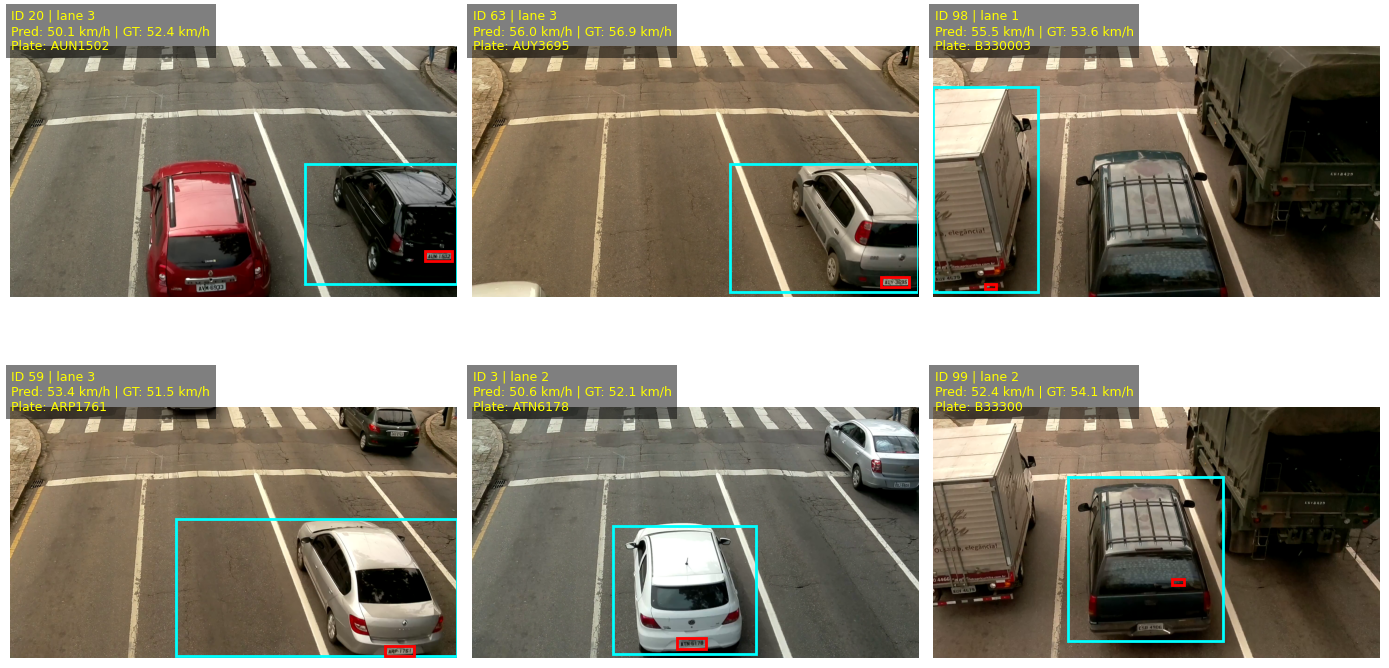

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# ============================================================
# Celda 3: mostrar ejemplos (para screenshots del informe)
# ============================================================

def show_speeding_examples_fastplate(df: pd.DataFrame,
                                     n: int = 6,
                                     figsize=(14, 8)) -> None:
    """
    Muestra algunos autos excedidos con:
      - bbox del auto (cyan)
      - bbox de la patente (rojo)
      - texto leído (FastPlate)
      - velocidades GT y estimada
    """
    df_ok = df.copy()
    df_ok = df_ok[df_ok["plate_detected"] & (df_ok["plate_text"].str.len() > 0)]
    if df_ok.empty:
        print("No hay ejemplos con patente detectada + OCR no vacío.")
        return

    df_sample = df_ok.sample(min(n, len(df_ok)), random_state=0)

    n_cols = 3
    n_rows = int(np.ceil(len(df_sample) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, df_sample.iterrows()):
        frame_idx = int(row["frame"])
        frame = load_frame(frame_idx, video_path=VIDEO_PATH)
        if frame is None:
            ax.axis("off")
            continue

        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.axis("off")

        # Auto (cyan)
        rect_car = patches.Rectangle(
            (row["veh_x1"], row["veh_y1"]),
            row["veh_x2"] - row["veh_x1"],
            row["veh_y2"] - row["veh_y1"],
            linewidth=2,
            edgecolor="cyan",
            facecolor="none",
        )
        ax.add_patch(rect_car)

        # Patente (rojo)
        if row["plate_detected"]:
            rect_plate = patches.Rectangle(
                (row["plate_x1"], row["plate_y1"]),
                row["plate_x2"] - row["plate_x1"],
                row["plate_y2"] - row["plate_y1"],
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect_plate)

        txt = f"ID {row['vehicle_id']} | lane {row['lane']}\n"
        txt += f"Pred: {row['speed_pred']:.1f} km/h"
        if not pd.isna(row["speed_gt"]):
            txt += f" | GT: {row['speed_gt']:.1f} km/h"
        txt += f"\nPlate: {row['plate_text']}"

        ax.text(
            5,
            15,
            txt,
            color="yellow",
            fontsize=9,
            bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
        )

    # Apagar ejes sobrantes
    for ax in axes[len(df_sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Llamada de ejemplo
show_speeding_examples_fastplate(df_speeding_plates_fastplate, n=6)


In [18]:
# ============================================================
# Celda 2 (nueva): usar todos los frames del track y votar patente
# ============================================================

import re

# Confirmamos que df_trap_reg_eval y df_tracks existen y tienen lo necesario
for col in ["vehicle_id", "lane", "gt_speed", "speed_trap_reg_lane_cal"]:
    if col not in df_trap_reg_eval.columns:
        raise ValueError(f"df_trap_reg_eval no tiene la columna '{col}'")

for col in ["vehicle_id", "frame", "x1", "y1", "x2", "y2"]:
    if col not in df_tracks.columns:
        raise ValueError(f"df_tracks no tiene la columna '{col}'")


def expand_bbox(bbox: Tuple[int, int, int, int],
                img_shape: Tuple[int, int, int],
                pad_x: int = 20,
                pad_y: int = 20) -> Tuple[int, int, int, int]:
    x1, y1, x2, y2 = bbox
    H, W = img_shape[:2]

    x1_e = max(x1 - pad_x, 0)
    y1_e = max(y1 - pad_y, 0)
    x2_e = min(x2 + pad_x, W - 1)
    y2_e = min(y2 + pad_y, H - 1)

    if x2_e <= x1_e or y2_e <= y1_e:
        return x1, y1, x2, y2
    return x1_e, y1_e, x2_e, y2_e


def is_valid_plate_format(text: str) -> bool:
    """
    Formato tipo AAA9999.
    """
    if not text:
        return False
    return bool(re.fullmatch(r"[A-Z]{3}[0-9]{4}", text))


# Autos excedidos según velocidad calibrada por carril
df_speeding = df_trap_reg_eval[df_trap_reg_eval["speed_trap_reg_lane_cal"] > SPEED_LIMIT].copy()
df_speeding = df_speeding.sort_values("vehicle_id").reset_index(drop=True)

print(f"Vehículos excedidos detectados por el sistema: {len(df_speeding)}")

rows = []

n_no_track = 0
n_no_plate_detections = 0
n_ocr_nonempty = 0
n_ocr_valid_format = 0

for _, r in df_speeding.iterrows():
    vid = int(r["vehicle_id"])
    lane = int(r["lane"]) if not pd.isna(r["lane"]) else None
    speed_pred = float(r["speed_trap_reg_lane_cal"])
    speed_gt = float(r["gt_speed"])

    track = df_tracks[df_tracks["vehicle_id"] == vid].copy()
    if track.empty:
        n_no_track += 1
        continue

    track = track.sort_values("frame")

    cand_records = []

    # Recorremos TODOS los frames donde aparece el vehículo
    for _, tr in track.iterrows():
        frame_idx = int(tr["frame"])
        car_bbox = (int(tr["x1"]), int(tr["y1"]), int(tr["x2"]), int(tr["y2"]))

        frame = load_frame(frame_idx, video_path=VIDEO_PATH)
        if frame is None:
            continue

        x1_roi, y1_roi, x2_roi, y2_roi = expand_bbox(car_bbox, frame.shape, pad_x=20, pad_y=20)
        roi = frame[y1_roi:y2_roi, x1_roi:x2_roi]

        plate_bbox_roi = detect_plate_region_luvizon(roi)
        if plate_bbox_roi is None:
            continue

        px1, py1, px2, py2 = plate_bbox_roi
        plate_x1 = x1_roi + px1
        plate_y1 = y1_roi + py1
        plate_x2 = x1_roi + px2
        plate_y2 = y1_roi + py2

        plate_crop = frame[plate_y1:plate_y2, plate_x1:plate_x2]
        plate_text = ocr_fastplate(plate_crop)

        if plate_text:
            n_ocr_nonempty += 1
        if is_valid_plate_format(plate_text):
            n_ocr_valid_format += 1

        cand_records.append(
            {
                "frame": frame_idx,
                "plate_x1": plate_x1,
                "plate_y1": plate_y1,
                "plate_x2": plate_x2,
                "plate_y2": plate_y2,
                "plate_text": plate_text,
            }
        )

    if not cand_records:
        n_no_plate_detections += 1
        rows.append(
            {
                "vehicle_id": vid,
                "lane": lane,
                "frame": np.nan,
                "speed_pred": speed_pred,
                "speed_gt": speed_gt,
                "veh_x1": np.nan,
                "veh_y1": np.nan,
                "veh_x2": np.nan,
                "veh_y2": np.nan,
                "plate_detected": False,
                "plate_x1": np.nan,
                "plate_y1": np.nan,
                "plate_x2": np.nan,
                "plate_y2": np.nan,
                "plate_text": "",
            }
        )
        continue

    cand_df = pd.DataFrame(cand_records)
    cand_df["valid_format"] = cand_df["plate_text"].apply(is_valid_plate_format)
    cand_df["plate_area"] = (cand_df["plate_x2"] - cand_df["plate_x1"]) * (
        cand_df["plate_y2"] - cand_df["plate_y1"]
    )

    # Voto por texto más frecuente; primero se intenta solo con formato válido
    vote_df = cand_df[cand_df["valid_format"]]
    if vote_df.empty:
        vote_df = cand_df

    best_text = vote_df["plate_text"].value_counts().idxmax()

    # Elegimos la detección con mayor área para ese texto
    best_rows = cand_df[cand_df["plate_text"] == best_text].copy()
    best_rows = best_rows.sort_values("plate_area", ascending=False)
    best = best_rows.iloc[0]

    rows.append(
        {
            "vehicle_id": vid,
            "lane": lane,
            "frame": int(best["frame"]),
            "speed_pred": speed_pred,
            "speed_gt": speed_gt,
            "veh_x1": int(track["x1"].min()),
            "veh_y1": int(track["y1"].min()),
            "veh_x2": int(track["x2"].max()),
            "veh_y2": int(track["y2"].max()),
            "plate_detected": True,
            "plate_x1": int(best["plate_x1"]),
            "plate_y1": int(best["plate_y1"]),
            "plate_x2": int(best["plate_x2"]),
            "plate_y2": int(best["plate_y2"]),
            "plate_text": best_text,
        }
    )

df_speeding_plates_fastplate = pd.DataFrame(rows)

print("Total filas en df_speeding_plates_fastplate:", len(df_speeding_plates_fastplate))
print("Sin track:", n_no_track,
      "| sin detecciones de placa:", n_no_plate_detections,
      "| OCR no vacío:", n_ocr_nonempty,
      "| OCR formato AAA9999:", n_ocr_valid_format)

df_speeding_plates_fastplate.head()


Vehículos excedidos detectados por el sistema: 37


Total filas en df_speeding_plates_fastplate: 37
Sin track: 0 | sin detecciones de placa: 0 | OCR no vacío: 944 | OCR formato AAA9999: 451


,vehicle_id,lane,frame,speed_pred,speed_gt,veh_x1,veh_y1,veh_x2,veh_y2,plate_detected,plate_x1,plate_y1,plate_x2,plate_y2,plate_text
0,1,3,83,58.370781,56.65,963,0,1920,1078,True,1236,312,1405,353,ADD0000
1,2,3,112,53.508414,53.74,651,0,1920,1077,True,1375,596,1497,629,BAI7690
2,3,2,186,50.582505,52.13,604,0,1223,1064,True,884,994,1007,1040,ATN6178
3,5,2,253,50.174985,50.51,607,0,1139,1066,True,793,931,997,973,ATU4297
4,7,1,283,59.992747,59.57,15,0,529,940,True,134,714,305,758,KRT6307


Ejemplos con buena lectura y formato AAA9999: 33


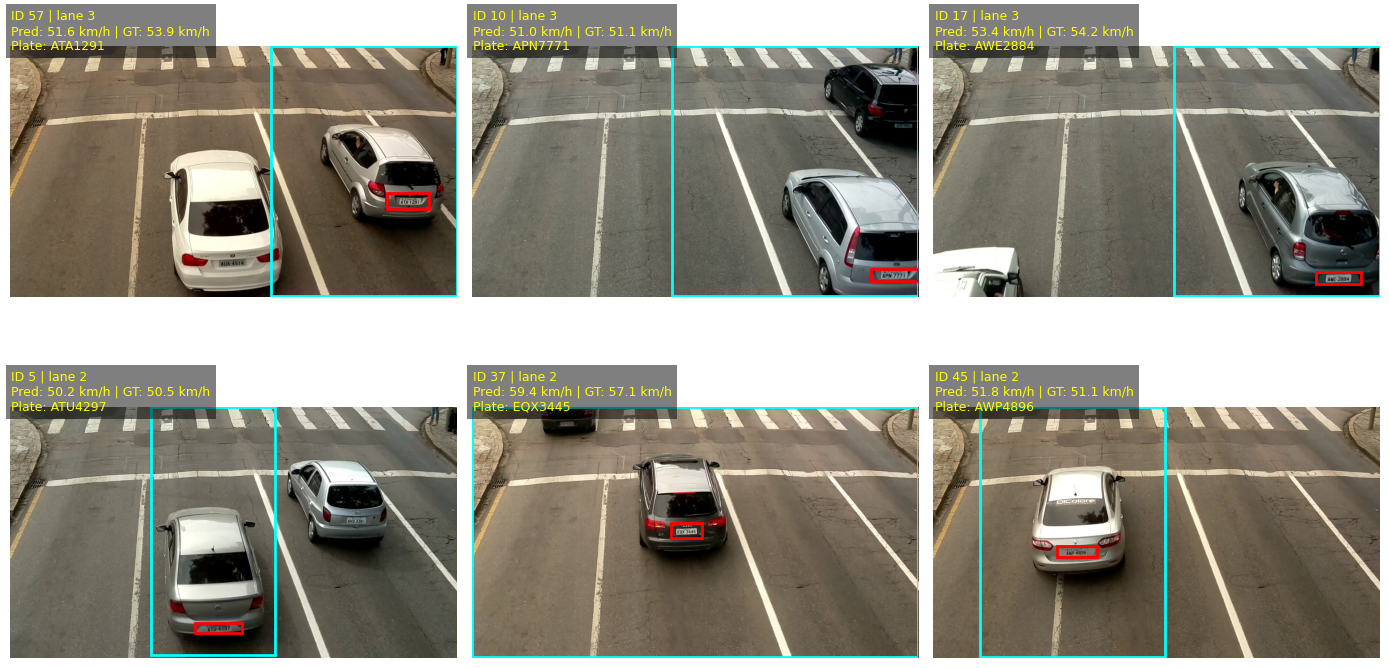

In [19]:
# ============================================================
# Celda 3 (nueva): elegir buenos ejemplos y mostrarlos
# ============================================================

def show_speeding_examples_fastplate(df: pd.DataFrame,
                                     n: int = 6,
                                     figsize=(14, 8)) -> None:
    if df.empty:
        print("No hay ejemplos para mostrar.")
        return

    n_cols = 3
    n_rows = int(np.ceil(min(n, len(df)) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, df.iterrows()):
        frame_idx = int(row["frame"])
        frame = load_frame(frame_idx, video_path=VIDEO_PATH)
        if frame is None:
            ax.axis("off")
            continue

        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.axis("off")

        # Auto (cyan)
        rect_car = patches.Rectangle(
            (row["veh_x1"], row["veh_y1"]),
            row["veh_x2"] - row["veh_x1"],
            row["veh_y2"] - row["veh_y1"],
            linewidth=2,
            edgecolor="cyan",
            facecolor="none",
        )
        ax.add_patch(rect_car)

        # Patente (rojo)
        rect_plate = patches.Rectangle(
            (row["plate_x1"], row["plate_y1"]),
            row["plate_x2"] - row["plate_x1"],
            row["plate_y2"] - row["plate_y1"],
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax.add_patch(rect_plate)

        txt = f"ID {row['vehicle_id']} | lane {row['lane']}\n"
        txt += f"Pred: {row['speed_pred']:.1f} km/h"
        if not pd.isna(row["speed_gt"]):
            txt += f" | GT: {row['speed_gt']:.1f} km/h"
        txt += f"\nPlate: {row['plate_text']}"

        ax.text(
            5,
            15,
            txt,
            color="yellow",
            fontsize=9,
            bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
        )

    for ax in axes[len(df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Filtrar “los que mejor dan”: formato AAA9999 y placa grande
df_best = df_speeding_plates_fastplate.copy()
df_best = df_best[df_best["plate_text"].apply(is_valid_plate_format)]
df_best["plate_area"] = (df_best["plate_x2"] - df_best["plate_x1"]) * (
    df_best["plate_y2"] - df_best["plate_y1"]
)
df_best = df_best.sort_values("plate_area", ascending=False).reset_index(drop=True)

print(f"Ejemplos con buena lectura y formato AAA9999: {len(df_best)}")

# Mostramos los top-N para usar en el informe
show_speeding_examples_fastplate(df_best.head(6), n=6)


In [20]:
import xml.etree.ElementTree as ET
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Hacer que VIDEO_PATH sea un Path aunque venga como str
_video_path_obj = Path(VIDEO_PATH)
XML_VEHICLES_PATH = _video_path_obj.parent / "vehicles.xml"
print("XML_VEHICLES_PATH:", XML_VEHICLES_PATH)

def build_df_gt_plates(xml_path: Path) -> pd.DataFrame:
    rows = []
    tree = ET.parse(str(xml_path))
    root = tree.getroot()

    for veh in root.findall(".//vehicle"):
        if veh.get("plate", "False").lower() != "true":
            continue

        lane = int(veh.get("lane"))
        iframe = int(veh.get("iframe"))

        region = veh.find("region")
        if region is None:
            continue

        x = int(region.get("x"))
        y = int(region.get("y"))
        w = int(region.get("w"))
        h = int(region.get("h"))

        rows.append(
            {
                "lane": lane,
                "frame_gt": iframe,
                "x1_gt": x,
                "y1_gt": y,
                "x2_gt": x + w,
                "y2_gt": y + h,
            }
        )

    return pd.DataFrame(rows)

df_gt_plates = build_df_gt_plates(XML_VEHICLES_PATH)
print("df_gt_plates shape:", df_gt_plates.shape)

def match_gt_plate(row, max_frame_diff: int = 20):
    """
    Busca en df_gt_plates la placa GT más cercana en tiempo dentro del mismo carril.
    """
    if pd.isna(row["frame"]) or pd.isna(row["lane"]):
        return None

    sub = df_gt_plates[df_gt_plates["lane"] == row["lane"]]
    if sub.empty:
        return None

    diffs = (sub["frame_gt"] - row["frame"]).abs()
    idx = diffs.idxmin()
    if diffs.loc[idx] > max_frame_diff:
        return None

    return sub.loc[idx]


XML_VEHICLES_PATH: video01\vehicles.xml
df_gt_plates shape: (115, 6)


Ejemplos con buena lectura y formato AAA9999: 33


C:\Users\bianc\AppData\Local\Temp\ipykernel_37056\3611905590.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


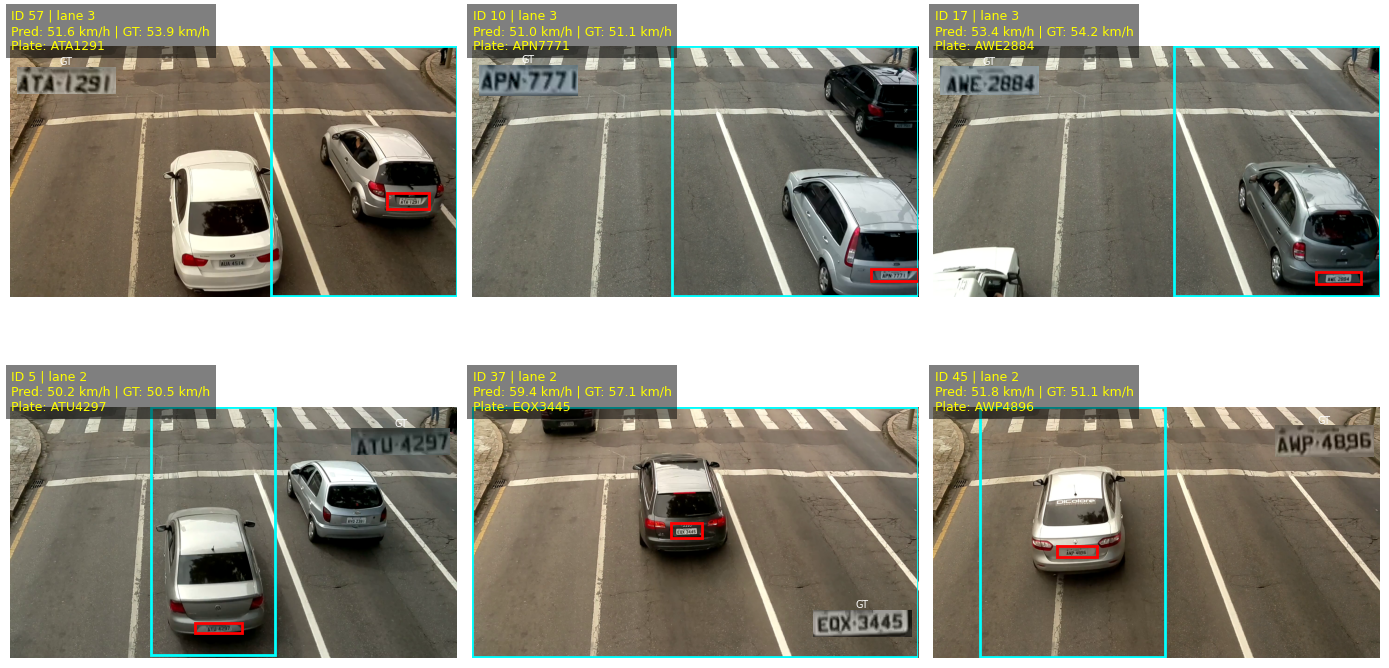

In [21]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def show_speeding_examples_with_gt(df: pd.DataFrame,
                                   n: int = 6,
                                   figsize=(14, 8)) -> None:
    if df.empty:
        print("No hay ejemplos para mostrar.")
        return

    n_cols = 3
    n_rows = int(np.ceil(min(n, len(df)) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, df.iterrows()):
        frame_idx = int(row["frame"])
        frame = load_frame(frame_idx, video_path=VIDEO_PATH)
        if frame is None:
            ax.axis("off")
            continue

        H, W, _ = frame.shape

        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.axis("off")

        # Auto (cyan)
        ax.add_patch(
            patches.Rectangle(
                (row["veh_x1"], row["veh_y1"]),
                row["veh_x2"] - row["veh_x1"],
                row["veh_y2"] - row["veh_y1"],
                linewidth=2,
                edgecolor="cyan",
                facecolor="none",
            )
        )

        # Patente detectada (rojo)
        ax.add_patch(
            patches.Rectangle(
                (row["plate_x1"], row["plate_y1"]),
                row["plate_x2"] - row["plate_x1"],
                row["plate_y2"] - row["plate_y1"],
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
        )

        txt = f"ID {row['vehicle_id']} | lane {row['lane']}\n"
        txt += f"Pred: {row['speed_pred']:.1f} km/h"
        if not pd.isna(row["speed_gt"]):
            txt += f" | GT: {row['speed_gt']:.1f} km/h"
        txt += f"\nPlate: {row['plate_text']}"

        ax.text(
            5,
            15,
            txt,
            color="yellow",
            fontsize=9,
            bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
        )

        # ---------- mini-crop GT en cuadrante opuesto a la patente ----------
        gt = match_gt_plate(row)
        if gt is not None:
            frame_gt = load_frame(int(gt["frame_gt"]), video_path=VIDEO_PATH)
            if frame_gt is not None:
                x1g, y1g, x2g, y2g = map(int, [gt["x1_gt"], gt["y1_gt"], gt["x2_gt"], gt["y2_gt"]])
                crop_gt = frame_gt[y1g:y2g, x1g:x2g]

                if crop_gt.size > 0:
                    # centro normalizado de la patente detectada
                    cx = (row["plate_x1"] + row["plate_x2"]) / 2.0 / W
                    cy = (row["plate_y1"] + row["plate_y2"]) / 2.0 / H

                    # elegimos cuadrante opuesto
                    if cx >= 0.5 and cy >= 0.5:
                        loc = "upper left"
                    elif cx < 0.5 and cy >= 0.5:
                        loc = "upper right"
                    elif cx >= 0.5 and cy < 0.5:
                        loc = "lower left"
                    else:
                        loc = "lower right"

                    ax_inset = inset_axes(ax, width="22%", height="22%", loc=loc)
                    ax_inset.imshow(cv2.cvtColor(crop_gt, cv2.COLOR_BGR2RGB))
                    ax_inset.set_title("GT", fontsize=7, color="white", pad=1)
                    ax_inset.axis("off")
        # -------------------------------------------------------------------

    for ax in axes[len(df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Reusamos los “mejores” ejemplos que ya tenías
df_best = df_speeding_plates_fastplate.copy()
df_best = df_best[df_best["plate_text"].apply(is_valid_plate_format)]
df_best["plate_area"] = (df_best["plate_x2"] - df_best["plate_x1"]) * (
    df_best["plate_y2"] - df_best["plate_y1"]
)
df_best = df_best.sort_values("plate_area", ascending=False).reset_index(drop=True)

print(f"Ejemplos con buena lectura y formato AAA9999: {len(df_best)}")

show_speeding_examples_with_gt(df_best.head(6), n=6)


Ejemplos con buena lectura y formato AAA9999: 33


C:\Users\bianc\AppData\Local\Temp\ipykernel_37056\186454691.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


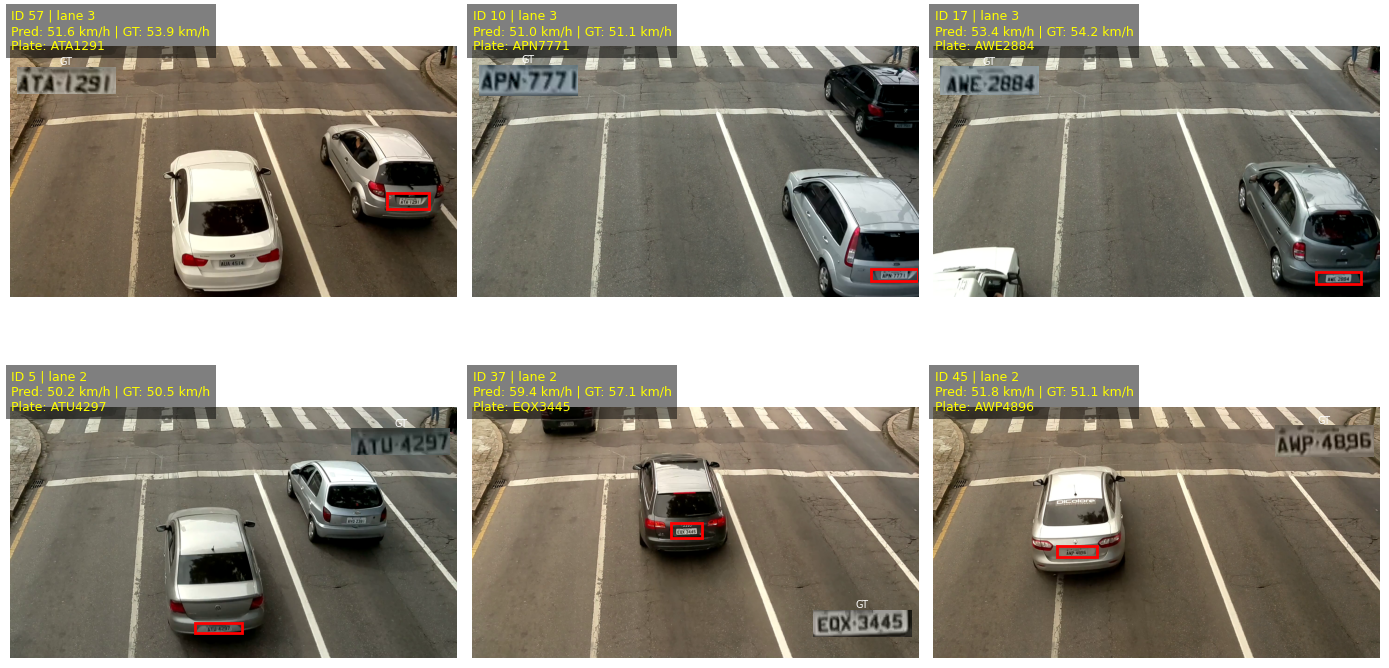

In [22]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def show_speeding_examples_with_gt(df: pd.DataFrame,
                                   n: int = 6,
                                   figsize=(14, 8)) -> None:
    if df.empty:
        print("No hay ejemplos para mostrar.")
        return

    n_cols = 3
    n_rows = int(np.ceil(min(n, len(df)) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, df.iterrows()):
        frame_idx = int(row["frame"])
        frame = load_frame(frame_idx, video_path=VIDEO_PATH)
        if frame is None:
            ax.axis("off")
            continue

        H, W, _ = frame.shape

        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.axis("off")

        # ---- solo bbox de patente detectada (rojo) ----
        ax.add_patch(
            patches.Rectangle(
                (row["plate_x1"], row["plate_y1"]),
                row["plate_x2"] - row["plate_x1"],
                row["plate_y2"] - row["plate_y1"],
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
        )

        # texto con info de velocidad y plate
        txt = f"ID {row['vehicle_id']} | lane {row['lane']}\n"
        txt += f"Pred: {row['speed_pred']:.1f} km/h"
        if not pd.isna(row["speed_gt"]):
            txt += f" | GT: {row['speed_gt']:.1f} km/h"
        txt += f"\nPlate: {row['plate_text']}"

        ax.text(
            5,
            15,
            txt,
            color="yellow",
            fontsize=9,
            bbox=dict(facecolor="black", alpha=0.5, edgecolor="none"),
        )

        # ---------- mini-crop GT en cuadrante opuesto ----------
        gt = match_gt_plate(row)
        if gt is not None:
            frame_gt = load_frame(int(gt["frame_gt"]), video_path=VIDEO_PATH)
            if frame_gt is not None:
                x1g, y1g, x2g, y2g = map(int, [gt["x1_gt"], gt["y1_gt"], gt["x2_gt"], gt["y2_gt"]])
                crop_gt = frame_gt[y1g:y2g, x1g:x2g]
                if crop_gt.size > 0:
                    # centro normalizado de la patente detectada
                    cx = (row["plate_x1"] + row["plate_x2"]) / 2.0 / W
                    cy = (row["plate_y1"] + row["plate_y2"]) / 2.0 / H

                    # cuadrante opuesto
                    if cx >= 0.5 and cy >= 0.5:
                        loc = "upper left"
                    elif cx < 0.5 and cy >= 0.5:
                        loc = "upper right"
                    elif cx >= 0.5 and cy < 0.5:
                        loc = "lower left"
                    else:
                        loc = "lower right"

                    ax_inset = inset_axes(ax, width="22%", height="22%", loc=loc)
                    ax_inset.imshow(cv2.cvtColor(crop_gt, cv2.COLOR_BGR2RGB))
                    ax_inset.set_title("GT", fontsize=7, color="white", pad=1)
                    ax_inset.axis("off")
        # -------------------------------------------------------

    for ax in axes[len(df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# volvemos a armar df_best y graficar
df_best = df_speeding_plates_fastplate.copy()
df_best = df_best[df_best["plate_text"].apply(is_valid_plate_format)]
df_best["plate_area"] = (df_best["plate_x2"] - df_best["plate_x1"]) * (
    df_best["plate_y2"] - df_best["plate_y1"]
)
df_best = df_best.sort_values("plate_area", ascending=False).reset_index(drop=True)

print(f"Ejemplos con buena lectura y formato AAA9999: {len(df_best)}")
show_speeding_examples_with_gt(df_best.head(6), n=6)


In [25]:
# ============================================================
# Celda 1: velocidades para TODOS los vehículos
#  - Regresión en la trap (como calibxcarril)
#  - Modelo pixel_speed -> km/h para los que no pisan bien la trap
# ============================================================

import pandas as pd
import numpy as np

# 1) Cargar tracks crudos desde el CSV original
df_tracks_for_video = pd.read_csv(TRACKS_CSV)

# --- FIX: sacar filas sin vehicle_id o sin lane antes de castear ---
df_tracks_for_video = df_tracks_for_video.dropna(subset=["vehicle_id", "lane"]).copy()

# Aseguramos tipos y bottom-center de la caja
df_tracks_for_video["vehicle_id"] = df_tracks_for_video["vehicle_id"].astype(int)
df_tracks_for_video["lane"] = df_tracks_for_video["lane"].astype(int)

df_tracks_for_video["px"] = (df_tracks_for_video["x1"] + df_tracks_for_video["x2"]) / 2.0
df_tracks_for_video["py"] = df_tracks_for_video["y2"].astype(float)

print("Tracks después de limpiar NaN en vehicle_id/lane:", df_tracks_for_video.shape)
display(df_tracks_for_video.head())

# 2) Velocidad geométrica por regresión dentro de la trap (MISMO MÉTODO que calibxcarril)
lane_configs_video = parse_lanes_xml(LANES_XML)
fps_video = get_video_fps(VIDEO_PATH)

df_trap_reg_video = compute_speed_trap_regression(
    df_tracks=df_tracks_for_video,
    lane_configs=lane_configs_video,
    fps=fps_video,
    margin_px=10,
    min_frames=5,
    use_axis="y",
)

df_trap_reg_video = df_trap_reg_video.copy()

# Si tenés lane_scales (K por carril), aplicarlos; si no, usar speed_trap_reg crudo
if "lane_scales" in globals():
    def _scale_row(r):
        return r["speed_trap_reg"] * lane_scales.get(int(r["lane"]), 1.0)
    df_trap_reg_video["speed_reg_kmh"] = df_trap_reg_video.apply(_scale_row, axis=1)
else:
    df_trap_reg_video["speed_reg_kmh"] = df_trap_reg_video["speed_trap_reg"]

print("Vehículos con velocidad por regresión en la trap:", df_trap_reg_video.shape[0])
display(df_trap_reg_video.head())

# 3) Merge: una velocidad por vehicle_id/carril para todos sus frames
df_tracks_for_video = df_tracks_for_video.merge(
    df_trap_reg_video[["vehicle_id", "lane", "speed_reg_kmh"]],
    on=["vehicle_id", "lane"],
    how="left",
)

# 4) Calcular velocidad en píxeles por vehículo (bottom-center moviéndose en y)
def _pixel_speed_for_vehicle(g: pd.DataFrame, fps: float) -> float:
    g = g.sort_values("frame")
    py = g["py"].to_numpy(dtype=float)
    if len(py) < 2:
        return 0.0
    dy = np.diff(py)
    v_pix = np.abs(dy) * fps   # píxeles/segundo
    return float(np.median(v_pix))

pixel_speeds = (
    df_tracks_for_video
    .groupby("vehicle_id")
    .apply(lambda g: _pixel_speed_for_vehicle(g, fps_video))
    .rename("pixel_speed")
    .reset_index()
)

df_tracks_for_video = df_tracks_for_video.merge(pixel_speeds, on="vehicle_id", how="left")
df_tracks_for_video["pixel_speed"] = df_tracks_for_video["pixel_speed"].fillna(0.0)

# 5) Entrenar modelo pixel_speed -> km/h con los que sí tienen speed_reg_kmh > 0
df_train = (
    df_tracks_for_video
    .dropna(subset=["speed_reg_kmh"])
    .query("speed_reg_kmh > 0 and pixel_speed > 0")
    .drop_duplicates("vehicle_id")
)

lane_models: dict[int, tuple[float, float]] = {}

if not df_train.empty:
    # Modelos por carril
    for lane, df_lane in df_train.groupby("lane"):
        if len(df_lane) < 5:
            continue
        x = df_lane["pixel_speed"].to_numpy(dtype=float)
        y = df_lane["speed_reg_kmh"].to_numpy(dtype=float)
        if np.all(x == 0):
            continue
        a, b = np.polyfit(x, y, 1)
        lane_models[int(lane)] = (a, b)

    # Modelo global
    xg = df_train["pixel_speed"].to_numpy(dtype=float)
    yg = df_train["speed_reg_kmh"].to_numpy(dtype=float)
    if np.all(xg == 0):
        a_global, b_global = 0.0, float(np.median(yg))
    else:
        a_global, b_global = np.polyfit(xg, yg, 1)
else:
    a_global, b_global = 0.0, 50.0  # fallback

print("Modelos por carril aprendidos:", lane_models)
print("Modelo global: km/h ≈ %.3f * pixel_speed + %.3f" % (a_global, b_global))

# 6) Definir velocidad final para el video
def _speed_for_video(row):
    v_reg = row.get("speed_reg_kmh", np.nan)
    if not np.isnan(v_reg) and v_reg > 0:
        return float(v_reg)

    pix = row["pixel_speed"]
    lane = row["lane"]
    if lane in lane_models:
        a, b = lane_models[lane]
        return max(0.0, a * pix + b)
    return max(0.0, a_global * pix + b_global)

df_tracks_for_video["speed_for_video"] = df_tracks_for_video.apply(_speed_for_video, axis=1)
df_tracks_for_video["is_speeder_for_video"] = df_tracks_for_video["speed_for_video"] > SPEED_LIMIT

print("Ejemplo de velocidades para video:")
display(
    df_tracks_for_video[
        ["frame", "vehicle_id", "lane", "speed_reg_kmh", "pixel_speed", "speed_for_video", "is_speeder_for_video"]
    ].head()
)


Tracks después de limpiar NaN en vehicle_id/lane: (5673, 19)


,video_id,frame,track_id,class_id,class_name,conf,x1,y1,x2,y2,img_w,img_h,fps,center_x,center_y,vehicle_id,lane,px,py
5,video,63,19,2,car,0.910427,1416.382080,843.590637,1920.0,1078.204468,1920,1080,25.0,1668.191040,960.897552,1,3,1668.191040,1078.204468
6,video,64,19,2,car,0.927916,1336.507202,785.973328,1920.0,1076.874268,1920,1080,25.0,1628.253601,931.423798,1,3,1628.253601,1076.874268
7,video,65,19,2,car,0.935446,1247.744629,720.804016,1920.0,1076.405518,1920,1080,25.0,1583.872314,898.604767,1,3,1583.872314,1076.405518
8,video,66,19,2,car,0.946423,1166.974731,657.293335,1920.0,1075.265991,1920,1080,25.0,1543.487366,866.279663,1,3,1543.487366,1075.265991
9,video,67,19,2,car,0.948359,1096.088379,597.837524,1920.0,1074.668701,1920,1080,25.0,1508.044189,836.253113,1,3,1508.044189,1074.668701


FPS leído del video: 25.0
Trap+Regresión: vehículos con velocidad estimada: 91
Vehículos con velocidad por regresión en la trap: 91


,vehicle_id,lane,speed_trap_reg,dist_m,delta_frames,n_points,speed_reg_kmh
0,1,3,33.533055,-4.081645,11,12,58.370781
1,2,3,30.739705,-4.359263,13,14,53.508414
2,3,2,29.691177,-4.304036,13,14,50.582505
3,4,3,27.915420,-4.600985,15,16,48.592199
4,5,2,29.451968,-4.263032,13,14,50.174985


Modelos por carril aprendidos: {1: (0.05057096035841557, 12.980542456086102), 2: (0.04306405903491275, 15.793843823995383), 3: (0.05307639580534093, 13.831520431244439)}
Modelo global: km/h ≈ 0.047 * pixel_speed + 15.358
Ejemplo de velocidades para video:


C:\Users\bianc\AppData\Local\Temp\ipykernel_37056\4166046116.py:72: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _pixel_speed_for_vehicle(g, fps_video))


,frame,vehicle_id,lane,speed_reg_kmh,pixel_speed,speed_for_video,is_speeder_for_video
0,63,1,3,58.370781,744.864655,58.370781,True
1,64,1,3,58.370781,744.864655,58.370781,True
2,65,1,3,58.370781,744.864655,58.370781,True
3,66,1,3,58.370781,744.864655,58.370781,True
4,67,1,3,58.370781,744.864655,58.370781,True


In [26]:
# ============================================================
# Celda 2: YOLO nuevo + matching de cajas + speed trap + patentes
# ============================================================

from ultralytics import YOLO
import cv2
import xml.etree.ElementTree as ET
import numpy as np

# 1) Cargar YOLO finetuneado (solo para las bounding boxes del video)
YOLO_WEIGHTS_NEW = r"C:\Users\bianc\Vision\tpf\speed\finetuned-detrac-weights.pt"
yolo_new = YOLO(YOLO_WEIGHTS_NEW)
print("Modelo YOLO nuevo cargado desde:", YOLO_WEIGHTS_NEW)


def iou_xyxy_np(boxA, boxB):
    """
    IoU entre cajas [x1,y1,x2,y2].
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter_w = max(0.0, xB - xA)
    inter_h = max(0.0, yB - yA)
    inter = inter_w * inter_h
    if inter <= 0.0:
        return 0.0

    areaA = max(0.0, boxA[2] - boxA[0]) * max(0.0, boxA[3] - boxA[1])
    areaB = max(0.0, boxB[2] - boxB[0]) * max(0.0, boxB[3] - boxB[1])
    denom = areaA + areaB - inter + 1e-9
    return inter / denom


def match_new_boxes_to_old(old_boxes, new_boxes, iou_thr=0.1):
    """
    Para cada bbox vieja (CSV) busca la nueva de YOLO con mayor IoU.
    Devuelve array de largo N con índices en new_boxes o -1 si no matchea.
    """
    old_boxes = np.asarray(old_boxes, dtype=float)
    new_boxes = np.asarray(new_boxes, dtype=float)

    N = old_boxes.shape[0]
    M = new_boxes.shape[0]
    matched = -np.ones(N, dtype=int)

    if N == 0 or M == 0:
        return matched

    used = set()
    for i in range(N):
        box_old = old_boxes[i]
        best_iou = 0.0
        best_j = -1
        for j in range(M):
            if j in used:
                continue
            box_new = new_boxes[j]
            iou = iou_xyxy_np(box_old, box_new)
            if iou > best_iou:
                best_iou = iou
                best_j = j
        if best_j >= 0 and best_iou >= iou_thr:
            matched[i] = best_j
            used.add(best_j)

    return matched


def load_speedtrap_polygons(xml_path):
    """
    Devuelve lista de polígonos (np.array Nx2) en coords de imagen
    a partir de lanes.xml.
    """
    polys = []
    tree = ET.parse(str(xml_path))
    root = tree.getroot()

    for measure in root.findall(".//measure"):
        pts = []
        for tag in ["pTopLeft", "pTopRight", "pBotRight", "pBotLeft"]:
            node = measure.find(tag)
            x = float(node.get("x"))
            y = float(node.get("y"))
            pts.append((x, y))
        polys.append(np.array(pts, dtype=np.int32))

    return polys


def draw_speedtrap_overlay(frame, polygons, alpha=0.25):
    """
    Dibuja la speed trap semi-transparente sobre el frame.
    """
    if not polygons:
        return frame

    overlay = frame.copy()
    color = (0, 255, 255)  # BGR (amarillo)

    for poly in polygons:
        cv2.fillPoly(overlay, [poly], color)

    cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0, dst=frame)
    return frame


# Polígonos de la trap
speedtrap_polygons = load_speedtrap_polygons(LANES_XML)
print("Polígonos de trap cargados:", len(speedtrap_polygons))

# Patentes por frame (excedidos con OCR no vacío)
df_plates_ok = df_speeding_plates_fastplate.copy()
df_plates_ok = df_plates_ok[
    df_plates_ok["plate_detected"] & (df_plates_ok["plate_text"].str.len() > 0)
]

plates_by_frame: dict[int, list[dict]] = {}
for row in df_plates_ok.itertuples(index=False):
    f = int(row.frame)
    plates_by_frame.setdefault(f, []).append(
        {
            "vehicle_id": int(row.vehicle_id),
            "x1": int(row.plate_x1),
            "y1": int(row.plate_y1),
            "x2": int(row.plate_x2),
            "y2": int(row.plate_y2),
            "text": str(row.plate_text),
        }
    )

print("Frames con patentes de excedidos:", len(plates_by_frame))


Modelo YOLO nuevo cargado desde: C:\Users\bianc\Vision\tpf\speed\finetuned-detrac-weights.pt
Polígonos de trap cargados: 3
Frames con patentes de excedidos: 37


In [27]:
# ============================================================
# Celda 3: generar VIDEO FINAL con
#  - bounding boxes del YOLO nuevo
#  - velocidad estimada para TODOS los autos
#  - patentes y OCR de los excedidos
# ============================================================

OUTPUT_FINAL_VIDEO = "video01/videofinal.mp4"

def make_final_video_videofinal(
    video_path,
    df_tracks_frame,
    plates_by_frame,
    polygons_speedtrap,
    output_path,
    speed_limit,
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"No se pudo abrir el video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = FPS_NOMINAL

    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Generando video final (videofinal) ({total_frames} frames)...")

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # 1) Pintar speed trap semi-transparente
        frame = draw_speedtrap_overlay(frame, polygons_speedtrap, alpha=0.25)

        # 2) Detecciones NUEVAS de YOLO en este frame (solo para bounding boxes)
        res = yolo_new(frame, verbose=False)[0]
        if res.boxes is not None and len(res.boxes) > 0:
            new_boxes_xyxy = res.boxes.xyxy.cpu().numpy()
        else:
            new_boxes_xyxy = np.zeros((0, 4), dtype=float)

        # 3) Tracks de este frame (con speed_for_video ya calculada)
        df_f = df_tracks_frame[df_tracks_frame["frame"] == frame_idx]

        if not df_f.empty:
            old_boxes = df_f[["x1", "y1", "x2", "y2"]].to_numpy(dtype=float)
            idx_match = match_new_boxes_to_old(old_boxes, new_boxes_xyxy, iou_thr=0.1)
        else:
            old_boxes = np.zeros((0, 4), dtype=float)
            idx_match = np.zeros(0, dtype=int)

        # 4) Dibujar cajas y velocidades
        for row_i, row in enumerate(df_f.itertuples(index=False)):
            # Caja: nueva si hay match, sino la original
            if idx_match.size > 0 and idx_match[row_i] >= 0:
                x1, y1, x2, y2 = new_boxes_xyxy[idx_match[row_i]]
            else:
                x1, y1, x2, y2 = row.x1, row.y1, row.x2, row.y2

            x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

            speed = float(row.speed_for_video)
            is_speeder = bool(row.is_speeder_for_video)

            # color según excedido o no
            color = (0, 255, 0)  # verde
            if is_speeder:
                color = (0, 0, 255)  # rojo

            # bounding box del vehículo
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # etiqueta de velocidad arriba de la caja
            label = f"{speed:.1f} km/h"
            if is_speeder:
                label += "  (EXCESO)"

            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)
            box_y1 = max(y1 - th - 10, 0)
            box_y2 = y1
            box_x1 = x1
            box_x2 = min(x1 + tw + 10, w - 1)

            cv2.rectangle(frame, (box_x1, box_y1), (box_x2, box_y2), (0, 0, 0), -1)
            cv2.putText(
                frame,
                label,
                (box_x1 + 5, box_y2 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )

        # 5) Patentes + texto OCR para los excedidos (frames con placa)
        if frame_idx in plates_by_frame:
            for p in plates_by_frame[frame_idx]:
                px1, py1 = int(p["x1"]), int(p["y1"])
                px2, py2 = int(p["x2"]), int(p["y2"])
                text = p["text"]

                cv2.rectangle(frame, (px1, py1), (px2, py2), (0, 255, 255), 2)

                (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2)
                ty1 = max(py1 - th - 10, 0)
                ty2 = py1
                tx1 = px1
                tx2 = min(px1 + tw + 10, w - 1)

                cv2.rectangle(frame, (tx1, ty1), (tx2, ty2), (0, 0, 0), -1)
                cv2.putText(
                    frame,
                    text,
                    (tx1 + 5, ty2 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.0,
                    (0, 255, 255),
                    2,
                    cv2.LINE_AA,
                )

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    print(f"Video final guardado en: {output_path}")


# Ejecutar
make_final_video_videofinal(
    video_path=VIDEO_PATH,
    df_tracks_frame=df_tracks_for_video,
    plates_by_frame=plates_by_frame,
    polygons_speedtrap=speedtrap_polygons,
    output_path=OUTPUT_FINAL_VIDEO,
    speed_limit=SPEED_LIMIT,
)


Generando video final (videofinal) (6918 frames)...
Video final guardado en: video01/videofinal.mp4
